# Dataset visualization

Inspects and analyzes a saved `BeamDataset` (`.pt` file) against the **current** `beam_optimization` configuration (`config/adige.py`): schema/composition, per-parameter and per-stage statistics, distributions, score, a single combined parameter/beam-state correlation matrix, and dataset coverage.

> This notebook is read-only: it only loads an existing dataset file, it does not run TraceWin and does not change anything on disk.

## 0. How this dataset was built

Every row here comes from one real TraceWin simulation, produced by `TraceWinDatasetBuilder`
(`env/dataset/tracewin_dataset_builder.py`):

1. **Sample parameters from a Gaussian centered on the machine defaults.** Independently for each of
   the `N_PARAMS` parameters: `value = default + Normal(0, sensitivity * DATASET_SCALE)`, then clipped
   to that parameter's hardware bounds (`hw_min`/`hw_max`). Parameters are drawn independently (a
   diagonal covariance, no correlation imposed at generation time) -- any correlation you see in
   section 5 is a real physics effect from TraceWin transport, not an artifact of how the samples were
   generated.
2. **Run the real simulator** on the sampled parameters (`simulator.simulate(params)`).
3. **Accept or reject.** A sample is kept if TraceWin returned a real result and either (a) the beam
   was transported successfully, or (b) all particles were lost partway through and TraceWin encoded
   that as a physics failure (the beam state is zeroed from the loss point onward) -- both outcomes are
   informative and kept. Only *technical* failures (simulator crashes, non-physical returns) are
   discarded, and the attempt is silently retried with a fresh draw.
4. **Repeat until `target_samples` accepted rows exist.** Every attempt draws from
   `np.random.default_rng(seed + attempt_index)`, so a whole build -- including which attempts failed --
   is exactly reproducible from one `seed`. Progress is checkpointed to `builder_state.json`, so an
   interrupted build resumes exactly where it left off; changing the sampling configuration (e.g. a
   different `DATASET_SCALE`) is detected and the build refuses to resume, rather than silently mixing
   two distributions in one file.
5. **Split 80/10/10** into train/val/test (shuffled with a fixed seed), saved alongside `dataset_all.pt`.

`DATASET_SCALE` is not an arbitrary width -- `exploration_scale_calculation` calibrates it to hit
roughly an **80% TraceWin success rate**, so the ~20% "all particles lost" rows you will see in
section 4 are intentional boundary-region coverage, not a building error (see also
`visualize_environments.ipynb`, which uses the same `DATASET_SCALE` for the RL environment's own reset
distribution).

In [1]:
from pathlib import Path
import math
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

WORKING_DIR = Path.cwd().resolve()
if (WORKING_DIR / 'beam_optimization').is_dir():
    REPO_ROOT = WORKING_DIR
else:
    PROJECT_ROOT = WORKING_DIR
    while PROJECT_ROOT.name != 'beam_optimization' and PROJECT_ROOT.parent != PROJECT_ROOT:
        PROJECT_ROOT = PROJECT_ROOT.parent
    REPO_ROOT = PROJECT_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from beam_optimization.config.adige import (
    BEAM_STATE_DIM, BEAM_STATE_FEATURES, DATASET_SCALE, ERROR_SCORE,
    N_OUTPUT_STAGES, N_PARAMS, N_STAGES, PARAMETERS, STAGE_MARKERS,
    default_params, params_to_vec, score_function_metadata, sensitivity_vec,
)
from beam_optimization.config.paths import default_dataset_path
from beam_optimization.env.dataset import BeamDataset


def fmt(value):
    return f'{float(value):.6g}'


def table(headers, rows):
    lines = ['| ' + ' | '.join(headers) + ' |', '| ' + ' | '.join(['---'] * len(headers)) + ' |']
    lines.extend('| ' + ' | '.join(str(cell) for cell in row) + ' |' for row in rows)
    return '\n'.join(lines)


def stage_label(index):
    """Match the beam0/marker_X convention used throughout the project."""
    if index == 0:
        return 'beam0'
    return f'marker_{STAGE_MARKERS[index]}'


def plot_grid_hist(data_list, labels, title, bins=60, ncols=6, cell_w=3.0, cell_h=2.1):
    n = len(data_list)
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(cell_w * ncols, cell_h * nrows))
    axes = np.atleast_1d(axes).reshape(nrows, ncols).ravel()
    for i, ax in enumerate(axes):
        if i >= n:
            ax.axis('off')
            continue
        values = np.asarray(data_list[i], dtype=float)
        ax.hist(values, bins=bins, alpha=0.85, color='steelblue', edgecolor='black', linewidth=0.3)
        ax.set_title(labels[i], fontsize=7.5)
        ax.tick_params(labelsize=6)
        ax.text(
            0.03, 0.95, f'μ={np.mean(values):.3g}\nσ={np.std(values):.3g}',
            transform=ax.transAxes, va='top', ha='left', fontsize=6,
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'),
        )
    fig.suptitle(title, fontsize=13, fontweight='bold')
    fig.tight_layout()
    plt.show()

## Modify here

Pin a specific dataset `.pt` file below, or leave it at its default to auto-discover the latest
numbered dataset (same convention every script/notebook in this project uses).

In [2]:
# <-- MODIFY HERE to inspect a different dataset.
DATASET_PATH_OVERRIDE = REPO_ROOT / 'beam_optimization/env/dataset/018/dataset_all.pt'
# e.g. DATASET_PATH_OVERRIDE = REPO_ROOT / 'beam_optimization/env/dataset/013/dataset_all.pt'
# None = auto (latest numbered dataset's dataset_all.pt)

In [3]:
def fmt_bound(value):
    return fmt(value) if value is not None else 'unbounded'

rows = []
for i, p in enumerate(PARAMETERS):
    std = p.sensitivity * DATASET_SCALE
    rows.append([
        i, f'`{p.name}`', fmt(p.default), fmt(p.sensitivity), fmt(std),
        f'[{fmt(p.default - std)}, {fmt(p.default + std)}]',
        f'[{fmt_bound(p.hw_min)}, {fmt_bound(p.hw_max)}]',
    ])

display(Markdown('\n\n'.join([
    '### 0.1 Sampling distribution, current config',
    (f'`DATASET_SCALE = {fmt(DATASET_SCALE)}`. Each parameter is drawn independently as '
     '`default + Normal(0, sensitivity * DATASET_SCALE)`, then clipped to `[hw_min, hw_max]` '
     '(most parameters currently have no recorded hardware bounds -- `hw_min`/`hw_max` are `None`, '
     'shown as "unbounded" below -- so clipping is a no-op for them today):'),
    table(
        ['#', 'Parameter', 'Default (center)', 'Sensitivity', 'Std = sensitivity*DATASET_SCALE',
         '1-sigma interval (pre-clip)', 'Hardware bounds'],
        rows,
    ),
    ('This is the *theoretical* generation formula, before clipping and before TraceWin '
     'acceptance/rejection -- compare against section 2.1 for what the dataset actually contains '
     'empirically once those effects are applied.'),
])))

### 0.1 Sampling distribution, current config

`DATASET_SCALE = 0.6`. Each parameter is drawn independently as `default + Normal(0, sensitivity * DATASET_SCALE)`, then clipped to `[hw_min, hw_max]` (most parameters currently have no recorded hardware bounds -- `hw_min`/`hw_max` are `None`, shown as "unbounded" below -- so clipping is a no-op for them today):

| # | Parameter | Default (center) | Sensitivity | Std = sensitivity*DATASET_SCALE | 1-sigma interval (pre-clip) | Hardware bounds |
| --- | --- | --- | --- | --- | --- | --- |
| 0 | `AD.SO.01` | 0.431132 | 0.000820368 | 0.000492221 | [0.43064, 0.431624] | [unbounded, unbounded] |
| 1 | `AD.SO.02` | 0.101112 | 0.00286712 | 0.00172027 | [0.0993912, 0.102832] | [unbounded, unbounded] |
| 2 | `AD.MS.03.X` | 4.07069e-06 | 0.000145997 | 8.75985e-05 | [-8.35278e-05, 9.16692e-05] | [unbounded, unbounded] |
| 3 | `AD.MS.03.Y` | -7.20273e-06 | 2.50454e-05 | 1.50273e-05 | [-2.223e-05, 7.82452e-06] | [unbounded, unbounded] |
| 4 | `AD.1EQ.01` | 192.308 | 23.6358 | 14.1815 | [178.127, 206.49] | [unbounded, unbounded] |
| 5 | `AD.MS.04.X` | -6.9039e-06 | 0.000451213 | 0.000270728 | [-0.000277632, 0.000263824] | [unbounded, unbounded] |
| 6 | `AD.MS.04.Y` | 1.42831e-06 | 0.000158963 | 9.5378e-05 | [-9.39497e-05, 9.68063e-05] | [unbounded, unbounded] |
| 7 | `AD.1EQ.02` | -7.93265 | 13.9122 | 8.34733 | [-16.28, 0.414682] | [unbounded, unbounded] |
| 8 | `AD.D.02` | -0.0462038 | 0.000225333 | 0.0001352 | [-0.046339, -0.0460686] | [unbounded, unbounded] |
| 9 | `AD.EM.6` | -234.602 | 10319.9 | 6191.97 | [-6426.57, 5957.37] | [unbounded, unbounded] |
| 10 | `AD.EM.8` | -1794.15 | 1050.44 | 630.266 | [-2424.41, -1163.88] | [unbounded, unbounded] |
| 11 | `AD.EM.10` | -595.895 | 597.884 | 358.73 | [-954.625, -237.164] | [unbounded, unbounded] |
| 12 | `AD.EM.12` | -1.59678 | 1418.99 | 851.394 | [-852.991, 849.797] | [unbounded, unbounded] |
| 13 | `AD.D.03` | 0.0462054 | 1.75083e-05 | 1.0505e-05 | [0.0461949, 0.0462159] | [unbounded, unbounded] |
| 14 | `AD.1EQ.03` | 5.56478 | 12.6891 | 7.61347 | [-2.04869, 13.1783] | [unbounded, unbounded] |
| 15 | `AD.MS.05.X` | -2.14688e-05 | 0.000456531 | 0.000273919 | [-0.000295387, 0.00025245] | [unbounded, unbounded] |
| 16 | `AD.MS.05.Y` | 2.66983e-06 | 0.000419017 | 0.00025141 | [-0.000248741, 0.00025408] | [unbounded, unbounded] |
| 17 | `AD.1EQ.04` | -193.18 | 55.4915 | 33.2949 | [-226.475, -159.885] | [unbounded, unbounded] |

This is the *theoretical* generation formula, before clipping and before TraceWin acceptance/rejection -- compare against section 2.1 for what the dataset actually contains empirically once those effects are applied.

In [4]:
DATASET_PATH = DATASET_PATH_OVERRIDE or default_dataset_path()
print(f'>>> Dataset selezionato: {DATASET_PATH}')

dataset = BeamDataset.load(DATASET_PATH)

n_samples = len(dataset)
param_vecs = dataset.get_param_vecs().numpy()             # (N, N_PARAMS), in PARAMETERS order
beam0 = dataset.get_initial_beam_states().numpy()          # (N, BEAM_STATE_DIM)
Y = dataset.Y.numpy()                                       # (N, N_OUTPUT_STAGES * BEAM_STATE_DIM)
scores = dataset.scores.numpy()                              # (N,) -- see note below

beam_stage_arrays = [beam0] + [
    Y[:, s * BEAM_STATE_DIM:(s + 1) * BEAM_STATE_DIM] for s in range(N_OUTPUT_STAGES)
]  # one (N, BEAM_STATE_DIM) array per stage, beam0 first, N_STAGES entries total

meta = score_function_metadata()
display(Markdown('\n\n'.join([
    '## 1. Dataset loaded',
    f'**Path:** `{DATASET_PATH}`',
    table(['Field', 'Value'], [
        ['Samples', f'{n_samples:,}'],
        ['X shape (beam0 + params)', str(tuple(dataset.X.shape))],
        ['Y shape (output stages, flattened)', str(tuple(dataset.Y.shape))],
        ['N_PARAMS', str(N_PARAMS)],
        ['N_STAGES (incl. beam0)', str(N_STAGES)],
        ['Score function', f"{meta['name']} v{meta['version']} (sha256 {meta['sha256'][:12]}...)"],
    ]),
    ('Scores are always **recomputed from the stored beam states using the current `score()` '
     'implementation** at load time (see `BeamDataset.load()`), so they reflect the live scoring '
     'logic below even if the dataset file itself is older.'),
])))

>>> Dataset selezionato: /mnt/meneghetti/FEDERICO_TESI/rl_beam_optimization/beam_optimization/env/dataset/018/dataset_all.pt
[BeamDataset] 35,000 samples loaded from /mnt/meneghetti/FEDERICO_TESI/rl_beam_optimization/beam_optimization/env/dataset/018/dataset_all.pt


## 1. Dataset loaded

**Path:** `/mnt/meneghetti/FEDERICO_TESI/rl_beam_optimization/beam_optimization/env/dataset/018/dataset_all.pt`

| Field | Value |
| --- | --- |
| Samples | 35,000 |
| X shape (beam0 + params) | (35000, 27) |
| Y shape (output stages, flattened) | (35000, 108) |
| N_PARAMS | 18 |
| N_STAGES (incl. beam0) | 13 |
| Score function | adige_linear_beam_quality v1 (sha256 61df22184976...) |

Scores are always **recomputed from the stored beam states using the current `score()` implementation** at load time (see `BeamDataset.load()`), so they reflect the live scoring logic below even if the dataset file itself is older.

## 2. Dataset composition

In [5]:
sens = sensitivity_vec()
param_rows = []
for i, p in enumerate(PARAMETERS):
    col = param_vecs[:, i]
    param_rows.append([
        i, f'`{p.name}`', fmt(p.default), fmt(p.sensitivity),
        fmt(col.min()), fmt(col.max()), fmt(col.mean()), fmt(col.std()),
    ])

beam_rows = []
for s_idx, arr in enumerate(beam_stage_arrays):
    for f_idx, fname in enumerate(BEAM_STATE_FEATURES):
        col = arr[:, f_idx]
        beam_rows.append([
            s_idx, f'`{stage_label(s_idx)}`', f'`{fname}`',
            fmt(col.min()), fmt(col.max()), fmt(col.mean()), fmt(col.std()),
        ])

display(Markdown('\n\n'.join([
    '### 2.1 Parameters -- dataset statistics vs. the `adige.py` spec (empirical; compare to section 0.1\'s generation formula)',
    table(
        ['#', 'Parameter', 'Default', 'Sensitivity', 'Dataset min', 'Dataset max', 'Dataset mean', 'Dataset std'],
        param_rows,
    ),
    '### 2.2 Beam-state features per stage',
    table(
        ['Stage', 'Label', 'Feature', 'Min', 'Max', 'Mean', 'Std'],
        beam_rows,
    ),
])))

### 2.1 Parameters -- dataset statistics vs. the `adige.py` spec (empirical; compare to section 0.1's generation formula)

| # | Parameter | Default | Sensitivity | Dataset min | Dataset max | Dataset mean | Dataset std |
| --- | --- | --- | --- | --- | --- | --- | --- |
| 0 | `AD.SO.01` | 0.431132 | 0.000820368 | 0.429204 | 0.433105 | 0.431136 | 0.00049141 |
| 1 | `AD.SO.02` | 0.101112 | 0.00286712 | 0.0935942 | 0.108407 | 0.101115 | 0.00171234 |
| 2 | `AD.MS.03.X` | 4.07069e-06 | 0.000145997 | -0.000344441 | 0.000380007 | 3.9004e-06 | 8.75179e-05 |
| 3 | `AD.MS.03.Y` | -7.20273e-06 | 2.50454e-05 | -7.27858e-05 | 5.38255e-05 | -7.10648e-06 | 1.49776e-05 |
| 4 | `AD.1EQ.01` | 192.308 | 23.6358 | 135.065 | 249.012 | 192.229 | 14.1927 |
| 5 | `AD.MS.04.X` | -6.9039e-06 | 0.000451213 | -0.00118751 | 0.00122485 | -5.37002e-06 | 0.000269941 |
| 6 | `AD.MS.04.Y` | 1.42831e-06 | 0.000158963 | -0.000351544 | 0.000398435 | 1.55514e-06 | 9.5258e-05 |
| 7 | `AD.1EQ.02` | -7.93265 | 13.9122 | -39.6277 | 27.3202 | -8.02135 | 8.29593 |
| 8 | `AD.D.02` | -0.0462038 | 0.000225333 | -0.046743 | -0.0456606 | -0.0462053 | 0.000135251 |
| 9 | `AD.EM.6` | -234.602 | 10319.9 | -24708.1 | 25039.3 | -253.168 | 6148.23 |
| 10 | `AD.EM.8` | -1794.15 | 1050.44 | -4381.55 | 578.596 | -1797.47 | 629.273 |
| 11 | `AD.EM.10` | -595.895 | 597.884 | -2073.06 | 915.849 | -593.317 | 359.596 |
| 12 | `AD.EM.12` | -1.59678 | 1418.99 | -3270.78 | 3719.11 | -3.15956 | 849.365 |
| 13 | `AD.D.03` | 0.0462054 | 1.75083e-05 | 0.0461628 | 0.046248 | 0.0462055 | 1.05022e-05 |
| 14 | `AD.1EQ.03` | 5.56478 | 12.6891 | -24.4364 | 37.3913 | 5.64742 | 7.66934 |
| 15 | `AD.MS.05.X` | -2.14688e-05 | 0.000456531 | -0.00117725 | 0.00112401 | -2.14476e-05 | 0.000274306 |
| 16 | `AD.MS.05.Y` | 2.66983e-06 | 0.000419017 | -0.00096991 | 0.0010021 | 4.18175e-06 | 0.000251992 |
| 17 | `AD.1EQ.04` | -193.18 | 55.4915 | -328.312 | -63.5234 | -193.276 | 33.4635 |

### 2.2 Beam-state features per stage

| Stage | Label | Feature | Min | Max | Mean | Std |
| --- | --- | --- | --- | --- | --- | --- |
| 0 | `beam0` | `npart_ratio` | 1 | 1 | 1 | 0 |
| 0 | `beam0` | `x0` | 4.70966e-08 | 4.70966e-08 | 4.70966e-08 | 0 |
| 0 | `beam0` | `y0` | 6.41029e-09 | 6.41029e-09 | 6.4103e-09 | 8.88178e-16 |
| 0 | `beam0` | `SizeX` | 5.76121 | 5.76121 | 5.76121 | 0 |
| 0 | `beam0` | `SizeY` | 5.75729 | 5.75729 | 5.75729 | 9.53674e-07 |
| 0 | `beam0` | `ex` | 0.0621569 | 0.0621569 | 0.0621569 | 1.49012e-08 |
| 0 | `beam0` | `ey` | 0.062038 | 0.062038 | 0.0620379 | 1.49012e-08 |
| 0 | `beam0` | `x'0` | 1.55977e-07 | 1.55977e-07 | 1.55977e-07 | 0 |
| 0 | `beam0` | `y'0` | -1.17833e-09 | -1.17833e-09 | -1.17833e-09 | 1.11022e-16 |
| 1 | `marker_2` | `npart_ratio` | 1 | 1 | 1 | 0 |
| 1 | `marker_2` | `x0` | -0.000319594 | -0.000307066 | -0.000315029 | 2.82064e-06 |
| 1 | `marker_2` | `y0` | 5.38966e-05 | 7.65211e-05 | 6.93098e-05 | 4.91104e-06 |
| 1 | `marker_2` | `SizeX` | 12.1168 | 12.2667 | 12.1925 | 0.0188787 |
| 1 | `marker_2` | `SizeY` | 12.1207 | 12.2705 | 12.1964 | 0.0188675 |
| 1 | `marker_2` | `ex` | 0.0677548 | 0.067807 | 0.0677824 | 6.469e-06 |
| 1 | `marker_2` | `ey` | 0.0673193 | 0.0673676 | 0.0673436 | 5.98988e-06 |
| 1 | `marker_2` | `x'0` | -0.00159772 | -0.0014726 | -0.00153271 | 2.65315e-05 |
| 1 | `marker_2` | `y'0` | 0.00175801 | 0.00186263 | 0.00181305 | 2.3644e-05 |
| 2 | `marker_29` | `npart_ratio` | 1 | 1 | 1 | 0 |
| 2 | `marker_29` | `x0` | -0.00100811 | -0.000181393 | -0.000775163 | 0.000127097 |
| 2 | `marker_29` | `y0` | 0.00195067 | 0.00233382 | 0.00209992 | 5.05202e-05 |
| 2 | `marker_29` | `SizeX` | 7.75707 | 8.42126 | 8.0968 | 0.0803438 |
| 2 | `marker_29` | `SizeY` | 7.74487 | 8.40992 | 8.08484 | 0.0804805 |
| 2 | `marker_29` | `ex` | 0.0734901 | 0.0738414 | 0.073673 | 4.30652e-05 |
| 2 | `marker_29` | `ey` | 0.0733027 | 0.0736393 | 0.0734721 | 4.27346e-05 |
| 2 | `marker_29` | `x'0` | 0.00025869 | 0.00107484 | 0.000517113 | 0.000140178 |
| 2 | `marker_29` | `y'0` | 0.00114461 | 0.0021166 | 0.00148323 | 0.000128613 |
| 3 | `marker_108` | `npart_ratio` | 0.5452 | 0.8114 | 0.758375 | 0.0244307 |
| 3 | `marker_108` | `x0` | -0.318326 | 0.580977 | 0.121615 | 0.0974987 |
| 3 | `marker_108` | `y0` | -3.49312 | 3.87655 | -0.0116454 | 0.817188 |
| 3 | `marker_108` | `SizeX` | 6.45078 | 6.75171 | 6.61829 | 0.0347573 |
| 3 | `marker_108` | `SizeY` | 5.36138 | 7.31058 | 7.05551 | 0.156351 |
| 3 | `marker_108` | `ex` | 0.059893 | 0.0631375 | 0.061844 | 0.000332116 |
| 3 | `marker_108` | `ey` | 0.0499889 | 0.0681664 | 0.0664263 | 0.00142597 |
| 3 | `marker_108` | `x'0` | -1.36426 | 1.95818 | 0.194169 | 0.373908 |
| 3 | `marker_108` | `y'0` | -8.89346 | 9.87107 | 0.0928632 | 2.20141 |
| 4 | `marker_151` | `npart_ratio` | 0.5452 | 0.8114 | 0.758375 | 0.0244307 |
| 4 | `marker_151` | `x0` | -1.09565 | 1.60826 | 0.231206 | 0.309023 |
| 4 | `marker_151` | `y0` | -9.1938 | 10.1368 | 0.0453268 | 2.21458 |
| 4 | `marker_151` | `SizeX` | 7.50091 | 7.82131 | 7.70135 | 0.0350228 |
| 4 | `marker_151` | `SizeY` | 7.03152 | 9.12774 | 8.88018 | 0.172789 |
| 4 | `marker_151` | `ex` | 0.0593803 | 0.0622392 | 0.061081 | 0.000299183 |
| 4 | `marker_151` | `ey` | 0.049366 | 0.06715 | 0.0655528 | 0.00144375 |
| 4 | `marker_151` | `x'0` | -0.939953 | 1.27105 | 0.109016 | 0.258075 |
| 4 | `marker_151` | `y'0` | -12.7031 | 13.411 | 0.107503 | 3.01329 |
| 5 | `marker_162` | `npart_ratio` | 0.5452 | 0.8114 | 0.758375 | 0.0244307 |
| 5 | `marker_162` | `x0` | -1.18961 | 1.73535 | 0.242122 | 0.334699 |
| 5 | `marker_162` | `y0` | -10.4641 | 11.4779 | 0.0560788 | 2.51583 |
| 5 | `marker_162` | `SizeX` | 7.47425 | 7.93208 | 7.73278 | 0.0554387 |
| 5 | `marker_162` | `SizeY` | 7.62895 | 9.93413 | 9.58682 | 0.187973 |
| 5 | `marker_162` | `ex` | 0.0592655 | 0.0620655 | 0.060914 | 0.000296739 |
| 5 | `marker_162` | `ey` | 0.0492637 | 0.0669425 | 0.0653481 | 0.00143835 |
| 5 | `marker_162` | `x'0` | -11.6633 | 10.1992 | 0.0647752 | 2.73753 |
| 5 | `marker_162` | `y'0` | -33.6552 | 32.9604 | -0.046145 | 8.29583 |
| 6 | `marker_195` | `npart_ratio` | 0.5452 | 0.8114 | 0.758375 | 0.0244309 |
| 6 | `marker_195` | `x0` | -6.39086 | 6.33305 | 0.27604 | 1.47538 |
| 6 | `marker_195` | `y0` | -22.2782 | 22.8022 | 0.0323693 | 5.67172 |
| 6 | `marker_195` | `SizeX` | 7.68278 | 9.05335 | 8.33697 | 0.176976 |
| 6 | `marker_195` | `SizeY` | 10.9942 | 14.4955 | 13.5632 | 0.302715 |
| 6 | `marker_195` | `ex` | 0.0587181 | 0.0614297 | 0.060176 | 0.000314739 |
| 6 | `marker_195` | `ey` | 0.0490784 | 0.0661243 | 0.0644369 | 0.00136354 |
| 6 | `marker_195` | `x'0` | -11.7209 | 10.3278 | 0.0702188 | 2.75767 |
| 6 | `marker_195` | `y'0` | -33.6786 | 32.5297 | -0.0467966 | 8.22155 |
| 7 | `marker_197` | `npart_ratio` | 0 | 0.8104 | 0.71005 | 0.164304 |
| 7 | `marker_197` | `x0` | -137.477 | 228.952 | 1.8928 | 12.5635 |
| 7 | `marker_197` | `y0` | -419.401 | 402.983 | 0.548838 | 27.015 |
| 7 | `marker_197` | `SizeX` | 0 | 299.624 | 12.067 | 24.1795 |
| 7 | `marker_197` | `SizeY` | 0 | 367.176 | 10.0919 | 28.5138 |
| 7 | `marker_197` | `ex` | 0 | 363.054 | 1.96638 | 15.643 |
| 7 | `marker_197` | `ey` | 0 | 68.3344 | 0.374287 | 2.23953 |
| 7 | `marker_197` | `x'0` | -1125.16 | 22.4265 | -17.3121 | 124.446 |
| 7 | `marker_197` | `y'0` | -391.699 | 386.768 | 0.513997 | 26.0325 |
| 8 | `marker_203` | `npart_ratio` | 0 | 0.8101 | 0.697185 | 0.199097 |
| 8 | `marker_203` | `x0` | -72.7011 | 107.535 | 1.89022 | 13.9131 |
| 8 | `marker_203` | `y0` | -44.7937 | 55.6938 | 0.0471662 | 4.67824 |
| 8 | `marker_203` | `SizeX` | 0 | 61.0814 | 9.97854 | 7.71911 |
| 8 | `marker_203` | `SizeY` | 0 | 69.2503 | 12.1005 | 5.43383 |
| 8 | `marker_203` | `ex` | 0 | 6.61667 | 0.229381 | 0.306166 |
| 8 | `marker_203` | `ey` | 0 | 11.7374 | 0.170009 | 0.247845 |
| 8 | `marker_203` | `x'0` | -102.237 | 172.895 | 1.44332 | 15.7643 |
| 8 | `marker_203` | `y'0` | -76.1093 | 100.468 | 0.0675397 | 8.05954 |
| 9 | `marker_205` | `npart_ratio` | 0 | 0.8025 | 0.676032 | 0.201174 |
| 9 | `marker_205` | `x0` | -248.031 | 151.135 | 1.33319 | 21.3419 |
| 9 | `marker_205` | `y0` | -50.1574 | 37.851 | -0.035199 | 6.53348 |
| 9 | `marker_205` | `SizeX` | 0 | 171.569 | 17.9562 | 16.1003 |
| 9 | `marker_205` | `SizeY` | 0 | 194.576 | 12.2675 | 4.75602 |
| 9 | `marker_205` | `ex` | 0 | 303.783 | 1.42298 | 4.13146 |
| 9 | `marker_205` | `ey` | 0 | 26.5788 | 0.300085 | 0.361593 |
| 9 | `marker_205` | `x'0` | -600.644 | 33.5792 | -1.5277 | 8.23532 |
| 9 | `marker_205` | `y'0` | -64.1236 | 40.0883 | 0.0398139 | 4.54117 |
| 10 | `marker_225` | `npart_ratio` | 0 | 0.8025 | 0.629705 | 0.211965 |
| 10 | `marker_225` | `x0` | -45.0999 | 43.3549 | 1.35297 | 10.8858 |
| 10 | `marker_225` | `y0` | -28.65 | 25.9013 | -0.0325718 | 5.14579 |
| 10 | `marker_225` | `SizeX` | 0 | 25.1043 | 9.17036 | 4.68008 |
| 10 | `marker_225` | `SizeY` | 0 | 24.3013 | 8.00733 | 2.64465 |
| 10 | `marker_225` | `ex` | 0 | 1.19892 | 0.116626 | 0.0630684 |
| 10 | `marker_225` | `ey` | 0 | 1.14204 | 0.206112 | 0.126823 |
| 10 | `marker_225` | `x'0` | -63.0738 | 27.3442 | 0.149533 | 4.20426 |
| 10 | `marker_225` | `y'0` | -22.7587 | 28.7402 | -0.00555251 | 4.41231 |
| 11 | `marker_261` | `npart_ratio` | 0 | 0.8025 | 0.629705 | 0.211965 |
| 11 | `marker_261` | `x0` | -50.8516 | 42.0903 | 1.40532 | 10.4388 |
| 11 | `marker_261` | `y0` | -27.6197 | 23.0369 | -0.0345167 | 4.46109 |
| 11 | `marker_261` | `SizeX` | 0 | 29.0565 | 9.67751 | 5.01501 |
| 11 | `marker_261` | `SizeY` | 0 | 30.3761 | 5.39666 | 2.32197 |
| 11 | `marker_261` | `ex` | 0 | 1.1989 | 0.116671 | 0.0631158 |
| 11 | `marker_261` | `ey` | 0 | 1.14204 | 0.205877 | 0.126698 |
| 11 | `marker_261` | `x'0` | -67.8456 | 36.0582 | 0.0382859 | 8.13734 |
| 11 | `marker_261` | `y'0` | -40.8325 | 37.5625 | -0.566589 | 8.73356 |
| 12 | `marker_332` | `npart_ratio` | 0 | 0.6547 | 0.153378 | 0.122401 |
| 12 | `marker_332` | `x0` | -9.8207 | 9.76355 | 0.293487 | 2.54943 |
| 12 | `marker_332` | `y0` | -9.03469 | 9.0134 | -0.118633 | 3.04589 |
| 12 | `marker_332` | `SizeX` | 0 | 7.75551 | 3.75922 | 1.64132 |
| 12 | `marker_332` | `SizeY` | 0 | 7.95403 | 3.25162 | 1.38658 |
| 12 | `marker_332` | `ex` | 0 | 0.215203 | 0.0263473 | 0.0162379 |
| 12 | `marker_332` | `ey` | 0 | 0.261828 | 0.045056 | 0.0214478 |
| 12 | `marker_332` | `x'0` | -28.2898 | 29.1755 | -0.125979 | 5.59524 |
| 12 | `marker_332` | `y'0` | -37.6517 | 24.8526 | -0.0280798 | 6.12026 |

## 3. Distributions

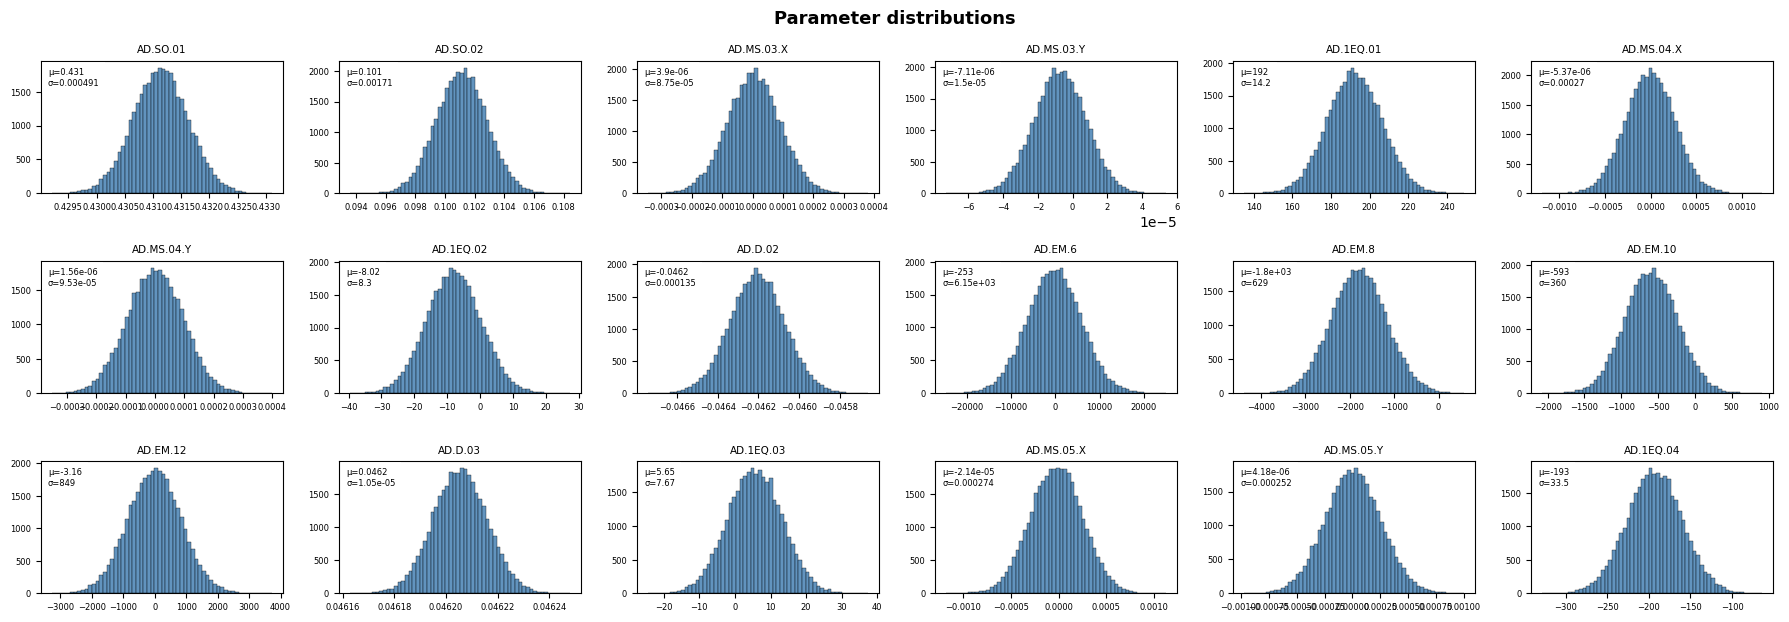

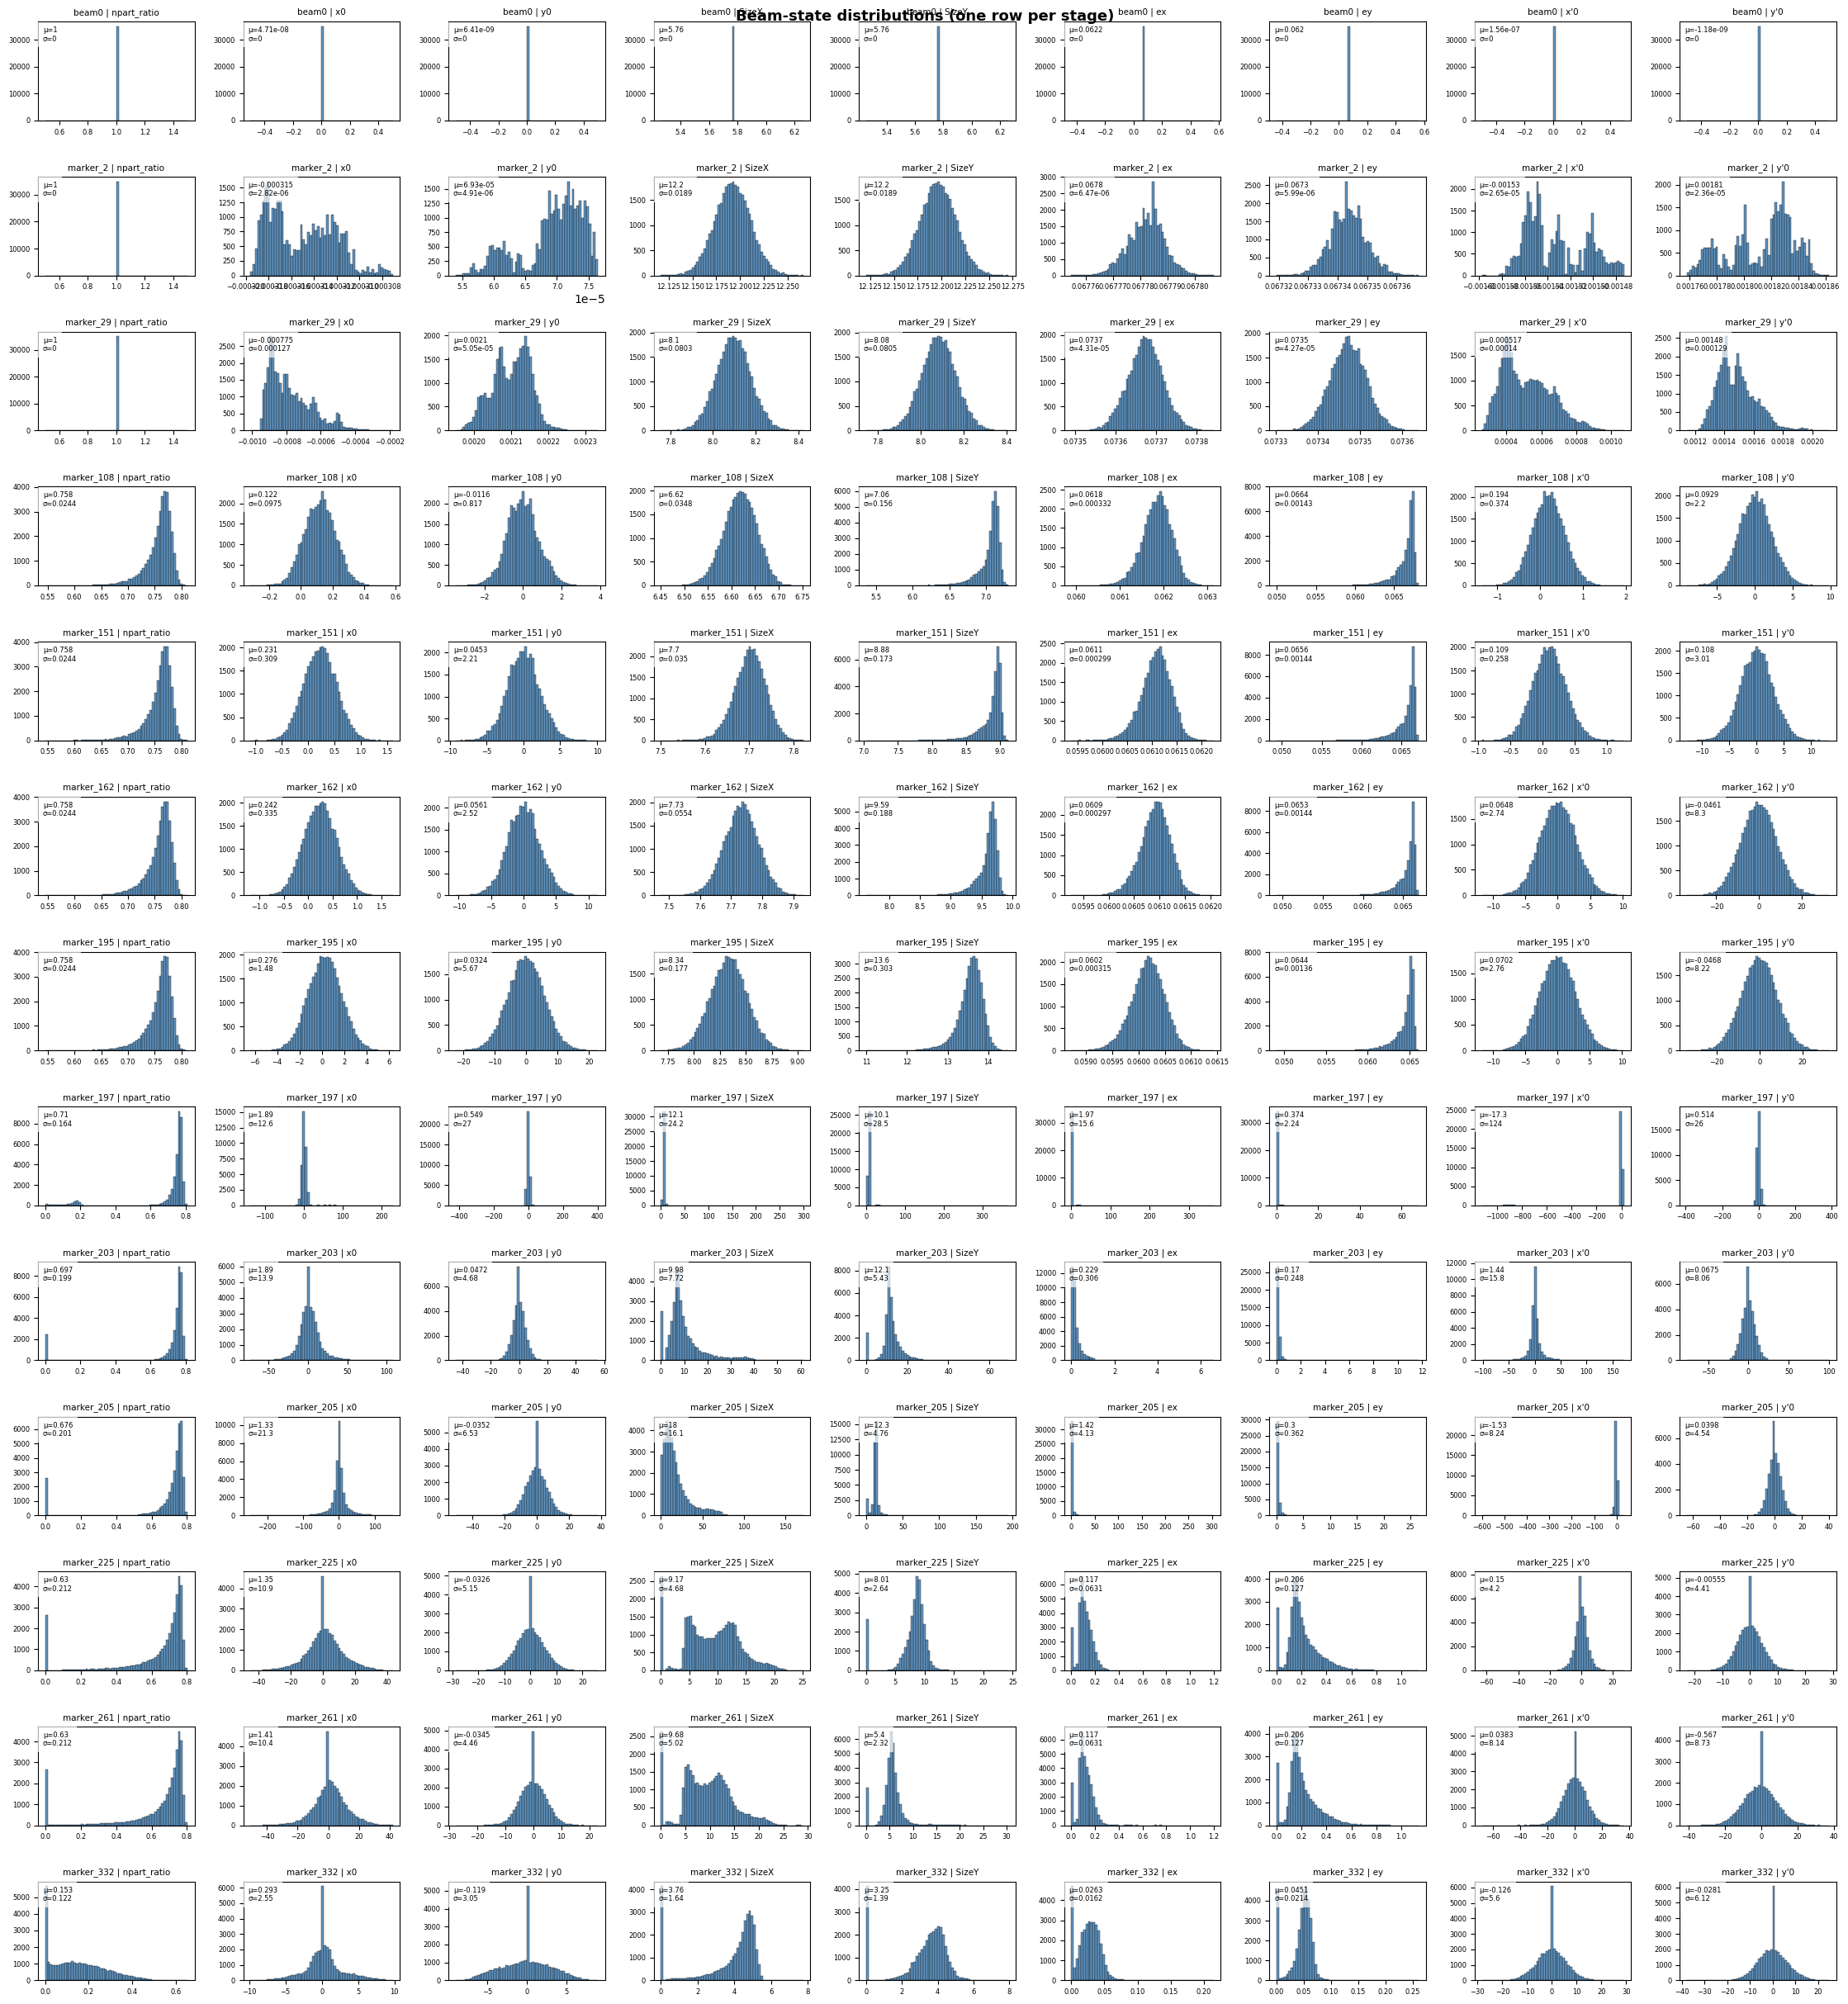

In [6]:
# --- Parameters ---
param_labels = [p.name for p in PARAMETERS]
plot_grid_hist(
    [param_vecs[:, i] for i in range(N_PARAMS)], param_labels,
    'Parameter distributions', ncols=6,
)

# --- Beam states: one grid row per stage (ncols = BEAM_STATE_DIM) ---
beam_labels = [f'{stage_label(s)} | {f}' for s in range(N_STAGES) for f in BEAM_STATE_FEATURES]
beam_data = [beam_stage_arrays[s][:, fi] for s in range(N_STAGES) for fi in range(BEAM_STATE_DIM)]
plot_grid_hist(
    beam_data, beam_labels, 'Beam-state distributions (one row per stage)',
    ncols=BEAM_STATE_DIM, cell_w=2.5, cell_h=1.9,
)

## 4. Score distribution

`DATASET_SCALE` is deliberately calibrated at an 80% (not 100%) success rate (see `exploration_scale_calculation`), so seeing a real fraction of `ERROR_SCORE` ("all particles lost") samples here is by design, not a bug -- it is exactly the ~20% of failure/near-boundary coverage the surrogate is meant to learn from.

Samples: 35000
ERROR_SCORE (-999, all particles lost): 4126 (11.8%)
Valid (non-error) scores: 30874 (88.2%)
  min=-46.1456  max=54.5458  mean=5.04441  std=14.3461
  P05 = -17.2081
  P50 = 4.36715
  P95 = 29.6369


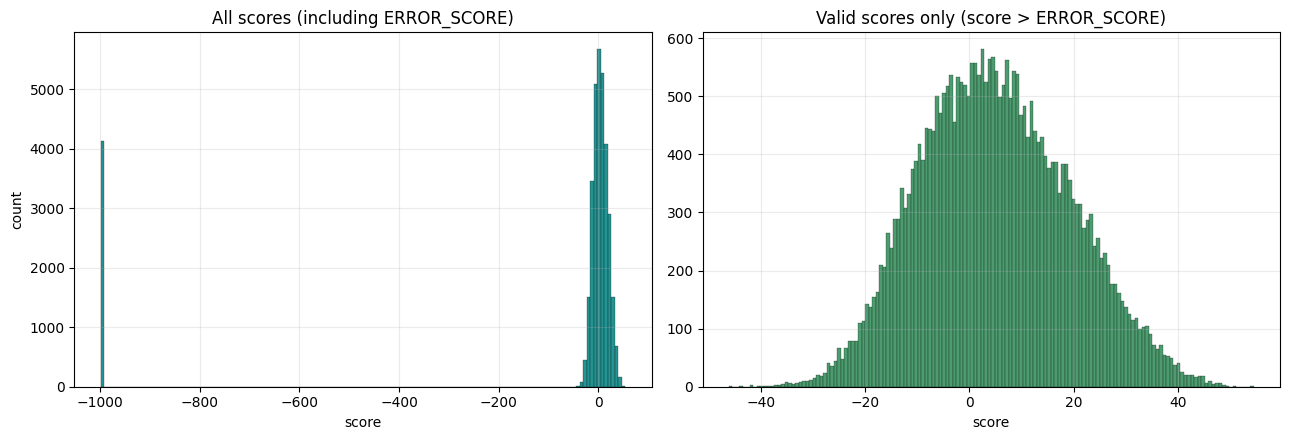

In [7]:
error_mask = scores <= ERROR_SCORE  # sentinel for "all particles lost" (score() clamps to exactly ERROR_SCORE)
n_error = int(error_mask.sum())
valid_scores = scores[~error_mask]

print(f'Samples: {n_samples}')
print(f'ERROR_SCORE ({fmt(ERROR_SCORE)}, all particles lost): {n_error} ({n_error / n_samples:.1%})')
print(f'Valid (non-error) scores: {len(valid_scores)} ({len(valid_scores) / n_samples:.1%})')
if len(valid_scores):
    print(f'  min={fmt(valid_scores.min())}  max={fmt(valid_scores.max())}  '
          f'mean={fmt(valid_scores.mean())}  std={fmt(valid_scores.std())}')
    for p in (5, 50, 95):
        print(f'  P{p:02d} = {fmt(np.percentile(valid_scores, p))}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(scores, bins=150, color='teal', alpha=0.85, edgecolor='black', linewidth=0.2)
axes[0].set_title('All scores (including ERROR_SCORE)')
axes[0].set_xlabel('score'); axes[0].set_ylabel('count'); axes[0].grid(alpha=0.25)
if len(valid_scores):
    axes[1].hist(valid_scores, bins=150, color='seagreen', alpha=0.85, edgecolor='black', linewidth=0.2)
axes[1].set_title('Valid scores only (score > ERROR_SCORE)')
axes[1].set_xlabel('score'); axes[1].grid(alpha=0.25)
fig.tight_layout()
plt.show()

## 5. Parameter <-> beam-state correlation

One combined Spearman correlation matrix: all `N_PARAMS` parameters (rows) against every beam-state feature at every stage (columns), computed in a single pass -- not one incremental heatmap per stage with a growing parameter subset.

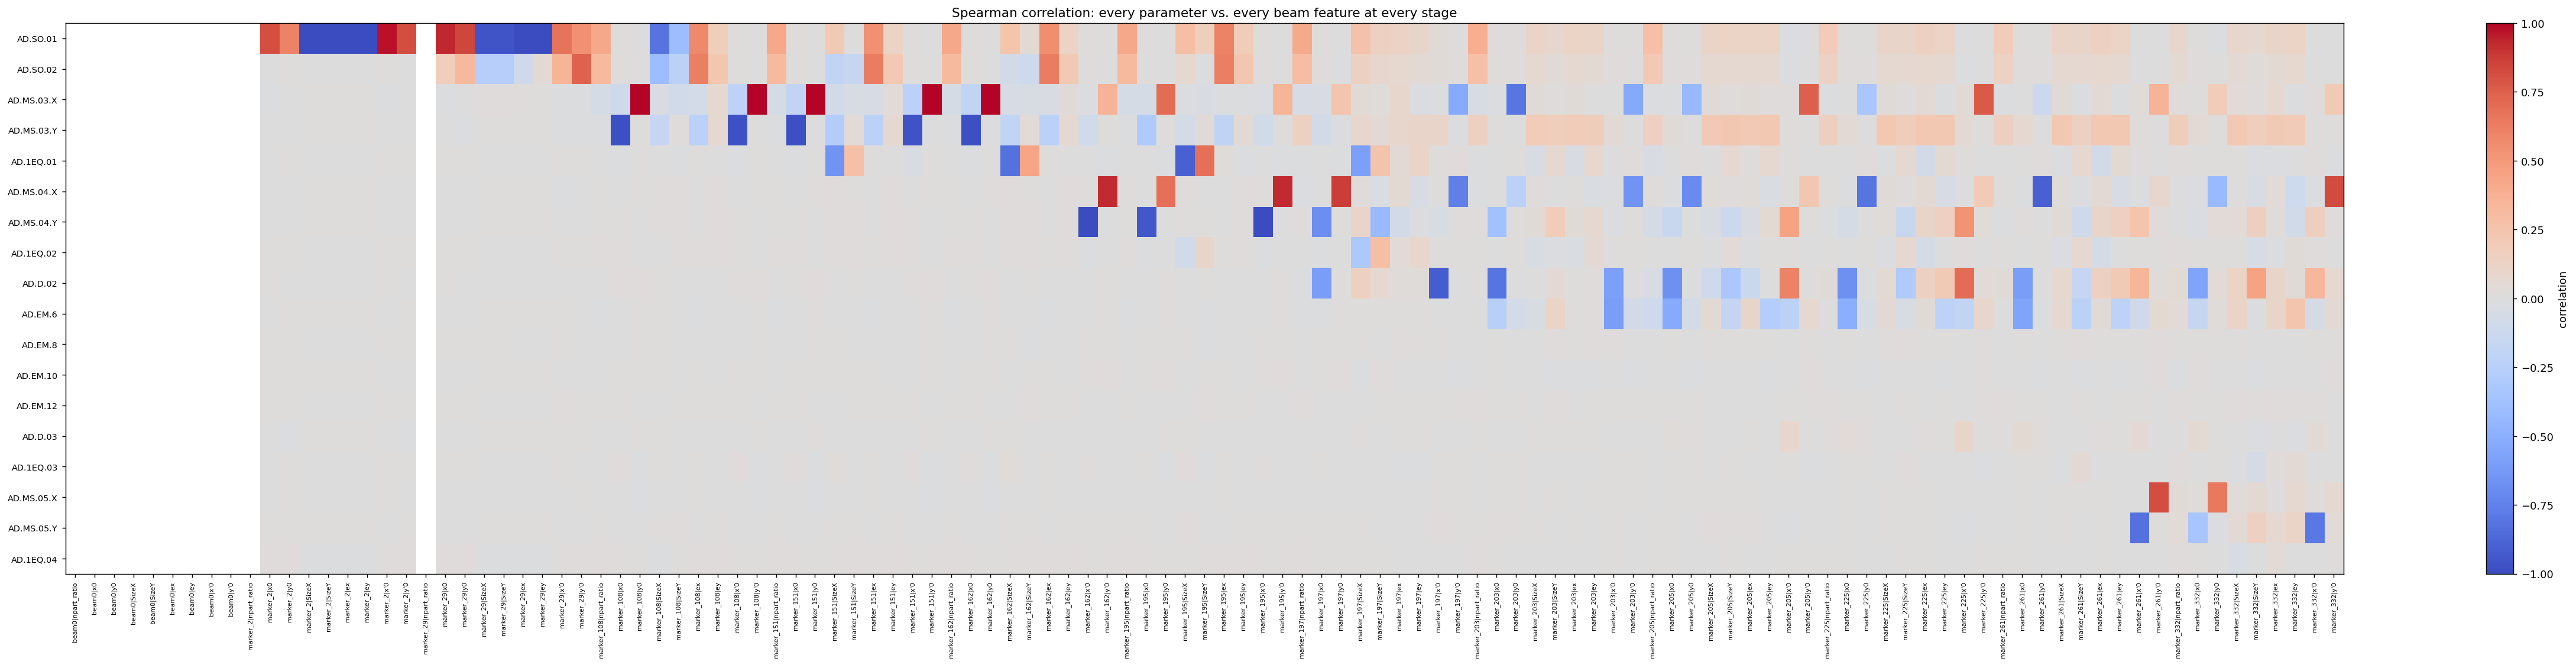

### Strongest parameter <-> beam-feature correlations (top 15 by |ρ|)

| Parameter | Beam feature | Spearman ρ |
| --- | --- | --- |
| AD.SO.01 | marker_2|SizeY | -1.000 |
| AD.SO.01 | marker_2|SizeX | -1.000 |
| AD.SO.01 | marker_2|ey | -1.000 |
| AD.SO.01 | marker_2|ex | -1.000 |
| AD.MS.03.X | marker_108|y'0 | +1.000 |
| AD.MS.03.X | marker_162|y0 | +1.000 |
| AD.MS.03.X | marker_151|y'0 | +1.000 |
| AD.MS.03.X | marker_151|y0 | +1.000 |
| AD.MS.03.X | marker_108|y0 | +0.999 |
| AD.SO.01 | marker_29|ey | -0.998 |
| AD.MS.04.Y | marker_162|x'0 | -0.995 |
| AD.MS.04.Y | marker_195|x'0 | -0.995 |
| AD.SO.01 | marker_29|ex | -0.994 |
| AD.MS.03.Y | marker_108|x0 | -0.980 |
| AD.MS.03.Y | marker_151|x0 | -0.979 |

In [8]:
beam_names = [f'{stage_label(s)}|{f}' for s in range(N_STAGES) for f in BEAM_STATE_FEATURES]
beam_matrix = np.concatenate(beam_stage_arrays, axis=1)  # (N, N_STAGES * BEAM_STATE_DIM)

df_params = pd.DataFrame(param_vecs, columns=[p.name for p in PARAMETERS])
df_beam = pd.DataFrame(beam_matrix, columns=beam_names)
corr = pd.concat([df_params, df_beam], axis=1).corr(method='spearman').loc[df_params.columns, df_beam.columns]

fig, ax = plt.subplots(figsize=(0.30 * len(beam_names) + 3, 0.32 * len(df_params.columns) + 3), dpi=130)
im = ax.imshow(corr.values, aspect='auto', cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(beam_names)))
ax.set_xticklabels(beam_names, rotation=90, fontsize=6)
ax.set_yticks(range(len(df_params.columns)))
ax.set_yticklabels(df_params.columns, fontsize=8)
ax.set_title('Spearman correlation: every parameter vs. every beam feature at every stage')
fig.colorbar(im, ax=ax, label='correlation')
fig.tight_layout()
plt.show()

flat = corr.stack().reset_index()
flat.columns = ['parameter', 'beam_feature', 'spearman']
flat['abs_corr'] = flat['spearman'].abs()
top = flat.sort_values('abs_corr', ascending=False).head(15)
display(Markdown('### Strongest parameter <-> beam-feature correlations (top 15 by |ρ|)\n\n' + table(
    ['Parameter', 'Beam feature', 'Spearman ρ'],
    [[row.parameter, row.beam_feature, f'{row.spearman:+.3f}'] for row in top.itertuples()],
)))

## 6. Dataset coverage

### Why self mean-KNN distance, in *this* notebook specifically

`render()` (`base_beam_env.py`) already plots a KNN-distance panel for an RL episode's visited
parameters, using `BeamDataset.param_knn_distance()` to say how far the policy strayed from the
training data. Repeating that computation here, on the dataset against *itself*, is not redundant --
it serves two purposes that only make sense at the dataset level:

- **Reference baseline.** A raw number like `KNN=2.3` for one RL-episode step is meaningless on its
  own -- is that close or far? This section's median/P95, computed over points that genuinely *are*
  in the dataset, is exactly the "normal/typical" scale to compare that number against.
- **Dataset self-diagnosis.** Near-zero distances flag likely duplicate/near-duplicate samples (a
  builder bug or insufficient randomness); the extreme upper tail flags isolated outlier points the
  surrogate has essentially no real neighbors to learn from.

Two plots below: (left) mean distance to the five nearest *other* dataset samples, matching the
environment's default `k=5`. It uses the real `dataset.param_knn_distance()` and removes the
mandatory zero-distance self-match analytically, so its sensitivity-normalized values are directly
comparable to the KNN panel and default distance penalty for a visited point; small = densely-sampled
region, large = isolated/sparse region. The right plot is a companion metric, RMS
deviation from `default_params()` in sensitivity units, with a `DATASET_SCALE` reference line -- a
direct sanity check that the dataset was actually generated at its intended calibrated width.

Mean-KNN sensitivity-normalized distance (k=5 other samples; self-match excluded):
  min=1.86293  max=4.87111  mean=2.84203  std=0.369106

RMS deviation from default_params(), in sensitivity units (target ~= DATASET_SCALE = 0.6):
  min=0.252094  max=1.01864  mean=0.591398  std=0.0988491


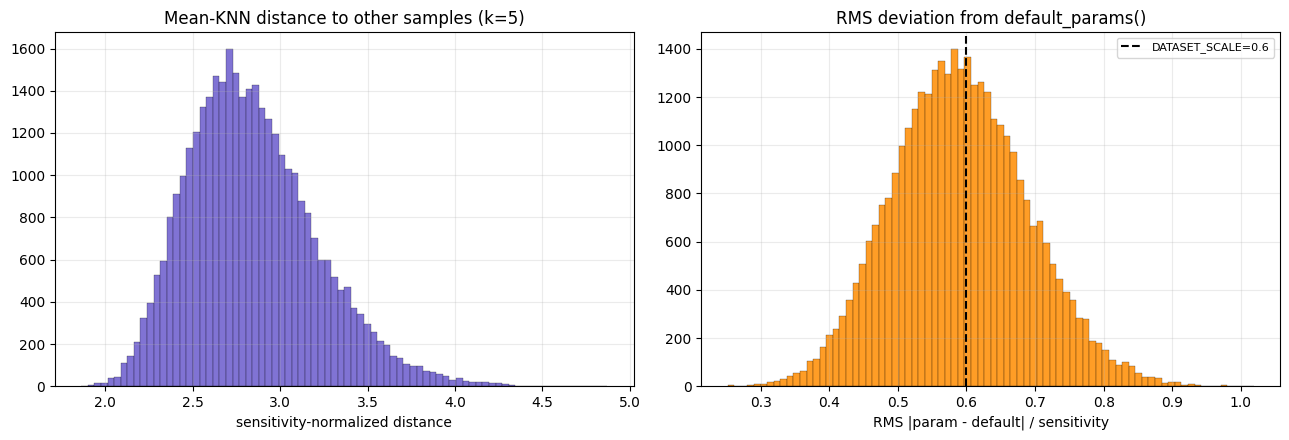

In [9]:
if n_samples < 2:
    raise ValueError('At least two samples are required for KNN coverage diagnostics.')
knn_k = min(5, n_samples - 1)
# Query k+1 because each row finds itself at distance zero. The method returns
# the mean over all k+1 values; multiplying by (k+1)/k removes that zero term
# and yields the mean distance to exactly k other samples.
self_knn_with_zero = dataset.param_knn_distance(param_vecs, k=knn_k + 1)
self_knn = self_knn_with_zero * ((knn_k + 1) / knn_k)

print(f'Mean-KNN sensitivity-normalized distance (k={knn_k} other samples; self-match excluded):')
print(f'  min={fmt(self_knn.min())}  max={fmt(self_knn.max())}  mean={fmt(self_knn.mean())}  std={fmt(self_knn.std())}')

default_vec = params_to_vec(default_params())
normalized_dev = (param_vecs - default_vec) / sens          # (N, N_PARAMS), in sensitivity units
radius = np.sqrt((normalized_dev ** 2).mean(axis=1))          # RMS per-parameter deviation, comparable to DATASET_SCALE

print(f'\nRMS deviation from default_params(), in sensitivity units (target ~= DATASET_SCALE = {fmt(DATASET_SCALE)}):')
print(f'  min={fmt(radius.min())}  max={fmt(radius.max())}  mean={fmt(radius.mean())}  std={fmt(radius.std())}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(self_knn, bins=80, color='slateblue', alpha=0.85, edgecolor='black', linewidth=0.2)
axes[0].set_title(f'Mean-KNN distance to other samples (k={knn_k})')
axes[0].set_xlabel('sensitivity-normalized distance'); axes[0].grid(alpha=0.25)

axes[1].hist(radius, bins=80, color='darkorange', alpha=0.85, edgecolor='black', linewidth=0.2)
axes[1].axvline(DATASET_SCALE, color='black', linestyle='--', label=f'DATASET_SCALE={fmt(DATASET_SCALE)}')
axes[1].set_title('RMS deviation from default_params()')
axes[1].set_xlabel('RMS |param - default| / sensitivity'); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.25)
fig.tight_layout()
plt.show()